In [ ]:
!pip install -q transformers datasets accelerate scikit-learn seaborn

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving opj_dataset.json to opj_dataset.json


In [ ]:
import json
import numpy as np
import torch
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    DataCollatorWithPadding, EarlyStoppingCallback,
    Trainer, TrainingArguments,
)

import matplotlib.pyplot as plt
import seaborn as sns

MODEL_NAME = "classla/bcms-bertic"
DATA_PATH = "opj_dataset.json"
OUTPUT_DIR = "./bertic-sentiment"
MAX_LEN = 128
SEED = 42
EPOCHS = 5
BATCH_SIZE = 16
LR = 2e-5

LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print("GPU dostupan:", torch.cuda.is_available())

GPU dostupan: True


UCITAVANJE DATASETA

In [ ]:
def load_data(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    texts, labels = [], []
    for i, item in enumerate(data):
        if item["sentiment"] not in LABEL2ID:
            raise ValueError(f"Nepoznat sentiment na indeksu {i}: {item['sentiment']}")
        texts.append(item["tekst"])
        labels.append(LABEL2ID[item["sentiment"]])
    return texts, labels

texts, labels = load_data(DATA_PATH)
print(f"Ukupno primera: {len(texts)}")

unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {ID2LABEL[u]}: {c}")

Ukupno primera: 2919
  negative: 964
  neutral: 1000
  positive: 955


PODELA NA TRAIN/VAL/TEST SKUP

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 2335 | Val: 292 | Test: 292


TOKENIZACIJA

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_dataset(texts, labels):
    ds = Dataset.from_dict({"text": texts, "label": labels})
    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)
    return ds.map(tokenize, batched=True, remove_columns=["text"])

train_ds = make_dataset(X_train, y_train)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

Map:   0%|          | 0/2335 [00:00<?, ? examples/s]

Map:   0%|          | 0/292 [00:00<?, ? examples/s]

Map:   0%|          | 0/292 [00:00<?, ? examples/s]

UCITAVANJE MODELA

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PARAMETRI

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    f1_weighted = f1_score(labels, preds, average="weighted", zero_division=0)
    return {
        "accuracy": acc, "precision_macro": precision,
        "recall_macro": recall, "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.06,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TRENING

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.991447,0.598734,0.760274,0.757226,0.761384,0.756128,0.755534


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

EVALUACIJA

              precision    recall  f1-score   support

    negative       0.92      0.82      0.87        96
     neutral       0.75      0.88      0.81       100
    positive       0.89      0.81      0.85        96

    accuracy                           0.84       292
   macro avg       0.85      0.84      0.84       292
weighted avg       0.85      0.84      0.84       292



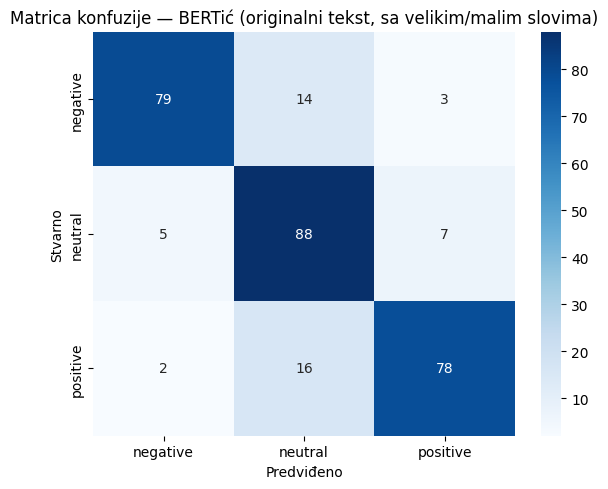

In [ ]:
test_results = trainer.predict(test_ds)
preds = np.argmax(test_results.predictions, axis=-1)
true = test_results.label_ids

labels_order = list(LABEL2ID.keys())
print(classification_report(true, preds, target_names=labels_order, zero_division=0))

cm = confusion_matrix(true, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title("Matrica konfuzije — BERTić (originalni tekst, sa velikim/malim slovima)")
plt.tight_layout()
plt.savefig("confusion_matrix_cased.png", dpi=150)
plt.show()

LOWERCASE

In [ ]:
texts_lower = [t.lower() for t in texts]

Xl_train, Xl_temp, yl_train, yl_temp = train_test_split(
    texts_lower, labels, test_size=0.2, random_state=SEED, stratify=labels
)
Xl_val, Xl_test, yl_val, yl_test = train_test_split(
    Xl_temp, yl_temp, test_size=0.5, random_state=SEED, stratify=yl_temp
)

print(f"Train: {len(Xl_train)} | Val: {len(Xl_val)} | Test: {len(Xl_test)}")

train_ds_lower = make_dataset(Xl_train, yl_train)
val_ds_lower = make_dataset(Xl_val, yl_val)
test_ds_lower = make_dataset(Xl_test, yl_test)

model_lower = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
)

training_args_lower = TrainingArguments(
    output_dir="./bertic-sentiment-lowercase",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.06,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_lower = Trainer(
    model=model_lower,
    args=training_args_lower,
    train_dataset=train_ds_lower,
    eval_dataset=val_ds_lower,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_lower.train()

Train: 2335 | Val: 292 | Test: 292


Map:   0%|          | 0/2335 [00:00<?, ? examples/s]

Map:   0%|          | 0/292 [00:00<?, ? examples/s]

Map:   0%|          | 0/292 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=730, training_loss=0.49490318494300317, metrics={'train_runtime': 264.411, 'train_samples_per_second': 44.155, 'train_steps_per_second': 2.761, 'total_flos': 767008501854336.0, 'train_loss': 0.49490318494300317, 'epoch': 5.0})

EVALUACIJA LOWERCASE

              precision    recall  f1-score   support

    negative       0.88      0.80      0.84        96
     neutral       0.76      0.83      0.79       100
    positive       0.85      0.84      0.85        96

    accuracy                           0.83       292
   macro avg       0.83      0.83      0.83       292
weighted avg       0.83      0.83      0.83       292



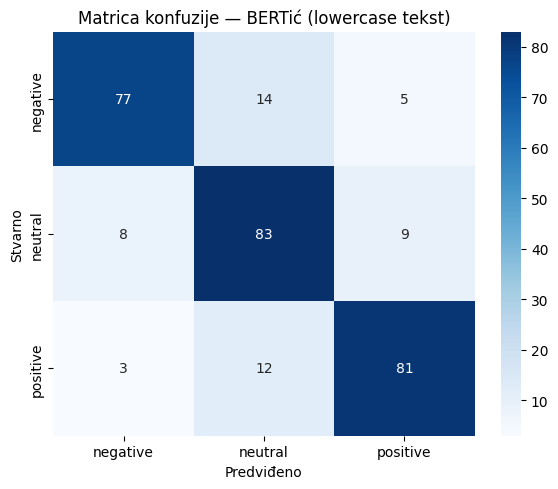

In [ ]:
test_results_lower = trainer_lower.predict(test_ds_lower)
preds_lower = np.argmax(test_results_lower.predictions, axis=-1)
true_lower = test_results_lower.label_ids

print(classification_report(true_lower, preds_lower, target_names=labels_order, zero_division=0))

cm_lower = confusion_matrix(true_lower, preds_lower)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lower, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title("Matrica konfuzije — BERTić (lowercase tekst)")
plt.tight_layout()
plt.savefig("confusion_matrix_lowercase.png", dpi=150)
plt.show()

SA ACCURACY UMESTO F1 MACRO

In [ ]:
model_acc = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
)

total_steps = (len(X_train) // BATCH_SIZE) * EPOCHS
warmup_steps = int(0.06 * total_steps)

training_args_acc = TrainingArguments(
    output_dir="./bertic-sentiment-accuracy",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_acc = Trainer(
    model=model_acc,
    args=training_args_acc,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_acc.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,1.012708,0.662883,0.739726,0.739544,0.739816,0.737513,0.737160
2,0.513917,0.507520,0.797945,0.797223,0.798267,0.797642,0.797305
3,0.382498,0.557907,0.780822,0.783357,0.782065,0.781506,0.780821
4,0.297935,0.600071,0.773973,0.774008,0.775326,0.773633,0.772852


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=584, training_loss=0.5458637394317208, metrics={'train_runtime': 295.6741, 'train_samples_per_second': 39.486, 'train_steps_per_second': 2.469, 'total_flos': 613358488195488.0, 'train_loss': 0.5458637394317208, 'epoch': 4.0})

EVALUACIJA SA ACCURACY

Accuracy (test skup):     0.8253
F1 macro (test skup):     0.8272
F1 weighted (test skup):  0.8267

              precision    recall  f1-score   support

    negative       0.90      0.83      0.86        96
     neutral       0.74      0.86      0.79       100
    positive       0.87      0.78      0.82        96

    accuracy                           0.83       292
   macro avg       0.84      0.82      0.83       292
weighted avg       0.83      0.83      0.83       292



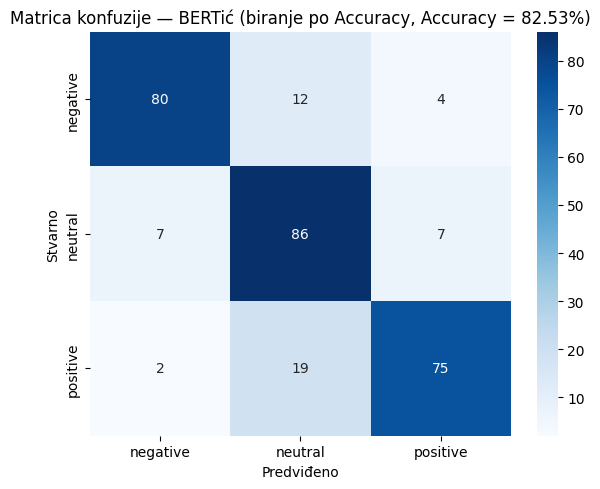

In [ ]:
test_results_acc = trainer_acc.predict(test_ds)
preds_acc = np.argmax(test_results_acc.predictions, axis=-1)
true_acc = test_results_acc.label_ids

acc_v2 = accuracy_score(true_acc, preds_acc)
f1_macro_v2 = f1_score(true_acc, preds_acc, average="macro")
f1_weighted_v2 = f1_score(true_acc, preds_acc, average="weighted")

print(f"Accuracy (test skup):     {acc_v2:.4f}")
print(f"F1 macro (test skup):     {f1_macro_v2:.4f}")
print(f"F1 weighted (test skup):  {f1_weighted_v2:.4f}\n")

print(classification_report(true_acc, preds_acc, target_names=labels_order, zero_division=0))

cm_acc = confusion_matrix(true_acc, preds_acc)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_acc, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title(f"Matrica konfuzije — BERTić (biranje po Accuracy, Accuracy = {acc_v2:.2%})")
plt.tight_layout()
plt.savefig("confusion_matrix_accuracy_selection.png", dpi=150)
plt.show()

LR1 = 1e-5

In [ ]:
LR_1 = 1e-5

model_lr1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
)

training_args_lr1 = TrainingArguments(
    output_dir="./bertic-sentiment-lr1e5",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR_1,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_lr1 = Trainer(
    model=model_lr1,
    args=training_args_lr1,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    processing_class=tokenizer,   # ako puca, zameni sa tokenizer=tokenizer
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_lr1.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,1.086718,0.884483,0.702055,0.696642,0.704098,0.696517,0.695246
2,0.646948,0.556972,0.777397,0.774272,0.778577,0.774300,0.773627
3,0.490059,0.520337,0.791096,0.794370,0.793313,0.786847,0.785995
4,0.383123,0.536856,0.791096,0.789167,0.792612,0.787884,0.787050
5,0.328824,0.535250,0.794521,0.792357,0.795666,0.792489,0.791789


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=730, training_loss=0.5993112825367549, metrics={'train_runtime': 234.3542, 'train_samples_per_second': 49.818, 'train_steps_per_second': 3.115, 'total_flos': 766950945794208.0, 'train_loss': 0.5993112825367549, 'epoch': 5.0})

EVALUACIJA 1e-5

Accuracy (test skup):     0.8390
F1 macro (test skup):     0.8408
F1 weighted (test skup):  0.8403

              precision    recall  f1-score   support

    negative       0.91      0.84      0.88        96
     neutral       0.76      0.85      0.80       100
    positive       0.87      0.82      0.84        96

    accuracy                           0.84       292
   macro avg       0.85      0.84      0.84       292
weighted avg       0.84      0.84      0.84       292



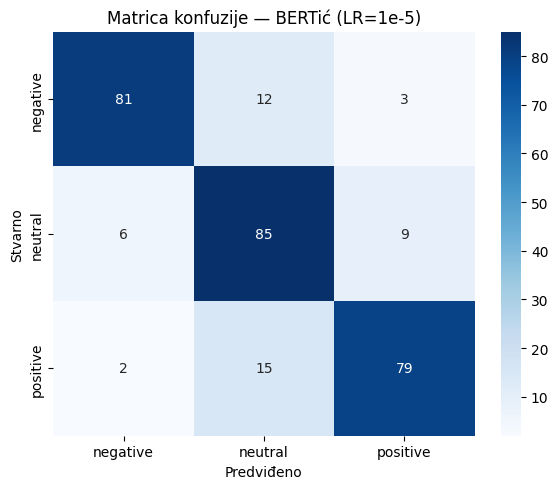

In [ ]:
test_results_lr1 = trainer_lr1.predict(test_ds)
preds_lr1 = np.argmax(test_results_lr1.predictions, axis=-1)
true_lr1 = test_results_lr1.label_ids

acc_lr1 = accuracy_score(true_lr1, preds_lr1)
f1_macro_lr1 = f1_score(true_lr1, preds_lr1, average="macro")
f1_weighted_lr1 = f1_score(true_lr1, preds_lr1, average="weighted")

print(f"Accuracy (test skup):     {acc_lr1:.4f}")
print(f"F1 macro (test skup):     {f1_macro_lr1:.4f}")
print(f"F1 weighted (test skup):  {f1_weighted_lr1:.4f}\n")

print(classification_report(true_lr1, preds_lr1, target_names=labels_order, zero_division=0))

cm_lr1 = confusion_matrix(true_lr1, preds_lr1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr1, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title(f"Matrica konfuzije — BERTić (LR=1e-5)")
plt.tight_layout()
plt.savefig("confusion_matrix_lr1e5.png", dpi=150)
plt.show()

3e-5

In [ ]:
LR_2 = 3e-5

model_lr2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
)

training_args_lr2 = TrainingArguments(
    output_dir="./bertic-sentiment-lr3e5",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR_2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_lr2 = Trainer(
    model=model_lr2,
    args=training_args_lr2,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    processing_class=tokenizer,   # ako puca, zameni sa tokenizer=tokenizer
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_lr2.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.887765,0.571764,0.760274,0.766364,0.761756,0.761624,0.760851
2,0.461592,0.533762,0.808219,0.812467,0.807813,0.808760,0.808491
3,0.353411,0.587643,0.791096,0.791985,0.792065,0.791505,0.790921
4,0.229718,0.727793,0.791096,0.789727,0.792787,0.787809,0.787010


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=584, training_loss=0.48058572534012467, metrics={'train_runtime': 146.0786, 'train_samples_per_second': 79.923, 'train_steps_per_second': 4.997, 'total_flos': 613358488195488.0, 'train_loss': 0.48058572534012467, 'epoch': 4.0})

EVALUACIJA 3e-5

Accuracy (test skup):     0.8425
F1 macro (test skup):     0.8442
F1 weighted (test skup):  0.8438

              precision    recall  f1-score   support

    negative       0.90      0.84      0.87        96
     neutral       0.76      0.87      0.81       100
    positive       0.90      0.81      0.85        96

    accuracy                           0.84       292
   macro avg       0.85      0.84      0.84       292
weighted avg       0.85      0.84      0.84       292



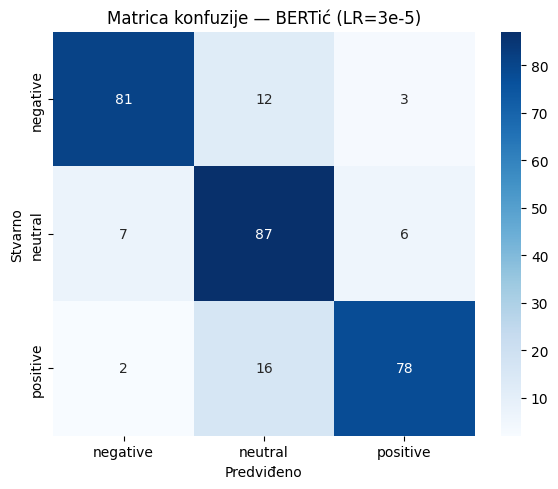

In [ ]:
test_results_lr2 = trainer_lr2.predict(test_ds)
preds_lr2 = np.argmax(test_results_lr2.predictions, axis=-1)
true_lr2 = test_results_lr2.label_ids

acc_lr2 = accuracy_score(true_lr2, preds_lr2)
f1_macro_lr2 = f1_score(true_lr2, preds_lr2, average="macro")
f1_weighted_lr2 = f1_score(true_lr2, preds_lr2, average="weighted")

print(f"Accuracy (test skup):     {acc_lr2:.4f}")
print(f"F1 macro (test skup):     {f1_macro_lr2:.4f}")
print(f"F1 weighted (test skup):  {f1_weighted_lr2:.4f}\n")

print(classification_report(true_lr2, preds_lr2, target_names=labels_order, zero_division=0))

cm_lr2 = confusion_matrix(true_lr2, preds_lr2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr2, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title(f"Matrica konfuzije — BERTić (LR=3e-5)")
plt.tight_layout()
plt.savefig("confusion_matrix_lr3e5.png", dpi=150)
plt.show()